# Evaluation

In [96]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt

from plotting import compute_accuracy_df, compute_accuracy_difference, get_plot_dict, get_plot_dict_stacked
from plotting import extract_answers
from plotting import run_test_categorical, test_flores, run_test_dynamic, run_test_static, test_static_vs_dynamic
from plotting import PlottingWrapper
from dotenv import load_dotenv

load_dotenv()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


True

## Helpers

In [100]:
from inference.evaluator import Evaluator

dataset_path = "gpt-4_1-nano"
evaluator = Evaluator(dataset_path=dataset_path)

persona_registry = evaluator.get_persona_registry()
answer_columns = persona_registry.get_answer_columns()
completion_columns = [col.replace("_answer", "") for col in answer_columns]
plotting_wrapper = PlottingWrapper(completion_columns)

2026-01-29 11:07:19  INFO     dataset_handler:_load               Preparing datasets
2026-01-29 11:07:19  INFO     dataset_handler:_download_dataset   Loading mmlu-pro
2026-01-29 11:07:19  INFO     dataset_handler:_download_dataset   Selecting a subset of 200 samples per category for category
2026-01-29 11:07:19  INFO     dataset_handler:_download_dataset   Dataframe length: 2800
2026-01-29 11:07:19  INFO     dataset_handler:_download_dataset   Loading MATH
2026-01-29 11:07:19  INFO     dataset_handler:_download_dataset   Selecting a subset of 200 samples per category for subject
2026-01-29 11:07:19  INFO     dataset_handler:_download_dataset   Dataframe length: 500
2026-01-29 11:07:19  INFO     dataset_handler:_download_dataset   Loading flores
2026-01-29 11:07:19  INFO     dataset_handler:_download_dataset   Selecting a subset of 200 samples per category for iso_639_3
2026-01-29 11:07:19  INFO     dataset_handler:_download_dataset   Dataframe length: 41400


In [101]:
extraction_columns = [f"{x}_option" for x in answer_columns]

In [99]:
length_dynamic_cols = [
    "base",
    "dynamic_short",
    "dynamic_long",
    "helpful_answer_option",
    "static_short_answer_option",
    "static_long_answer_option",
    "beginner_teacher_answer_option",
    "intermediate_teacher_answer_option",
    "expert_teacher_answer_option",
]

# 1. persona vs. baseline
# 2. measuring effects of properties with regression
# 3. static vs. dynamic
# for discussion: findings between open and closed
# find title!!
# no acknowledgments
# next meeting: 14.01.2025 @ 14:00

## MMLU Evaluation

In [102]:
mmlu_tasks, mmlu_df = evaluator.get_data("mmlu-pro")
mmlu_df = extract_answers(mmlu_df, answer_columns, "mmlu")

In [103]:
accuracy_df = compute_accuracy_df(mmlu_df, completion_columns)
gains_baseline_df = compute_accuracy_difference(accuracy_df, "no", ["helpful"])
gains_helpful_df = compute_accuracy_difference(accuracy_df, "helpful", ["no"])

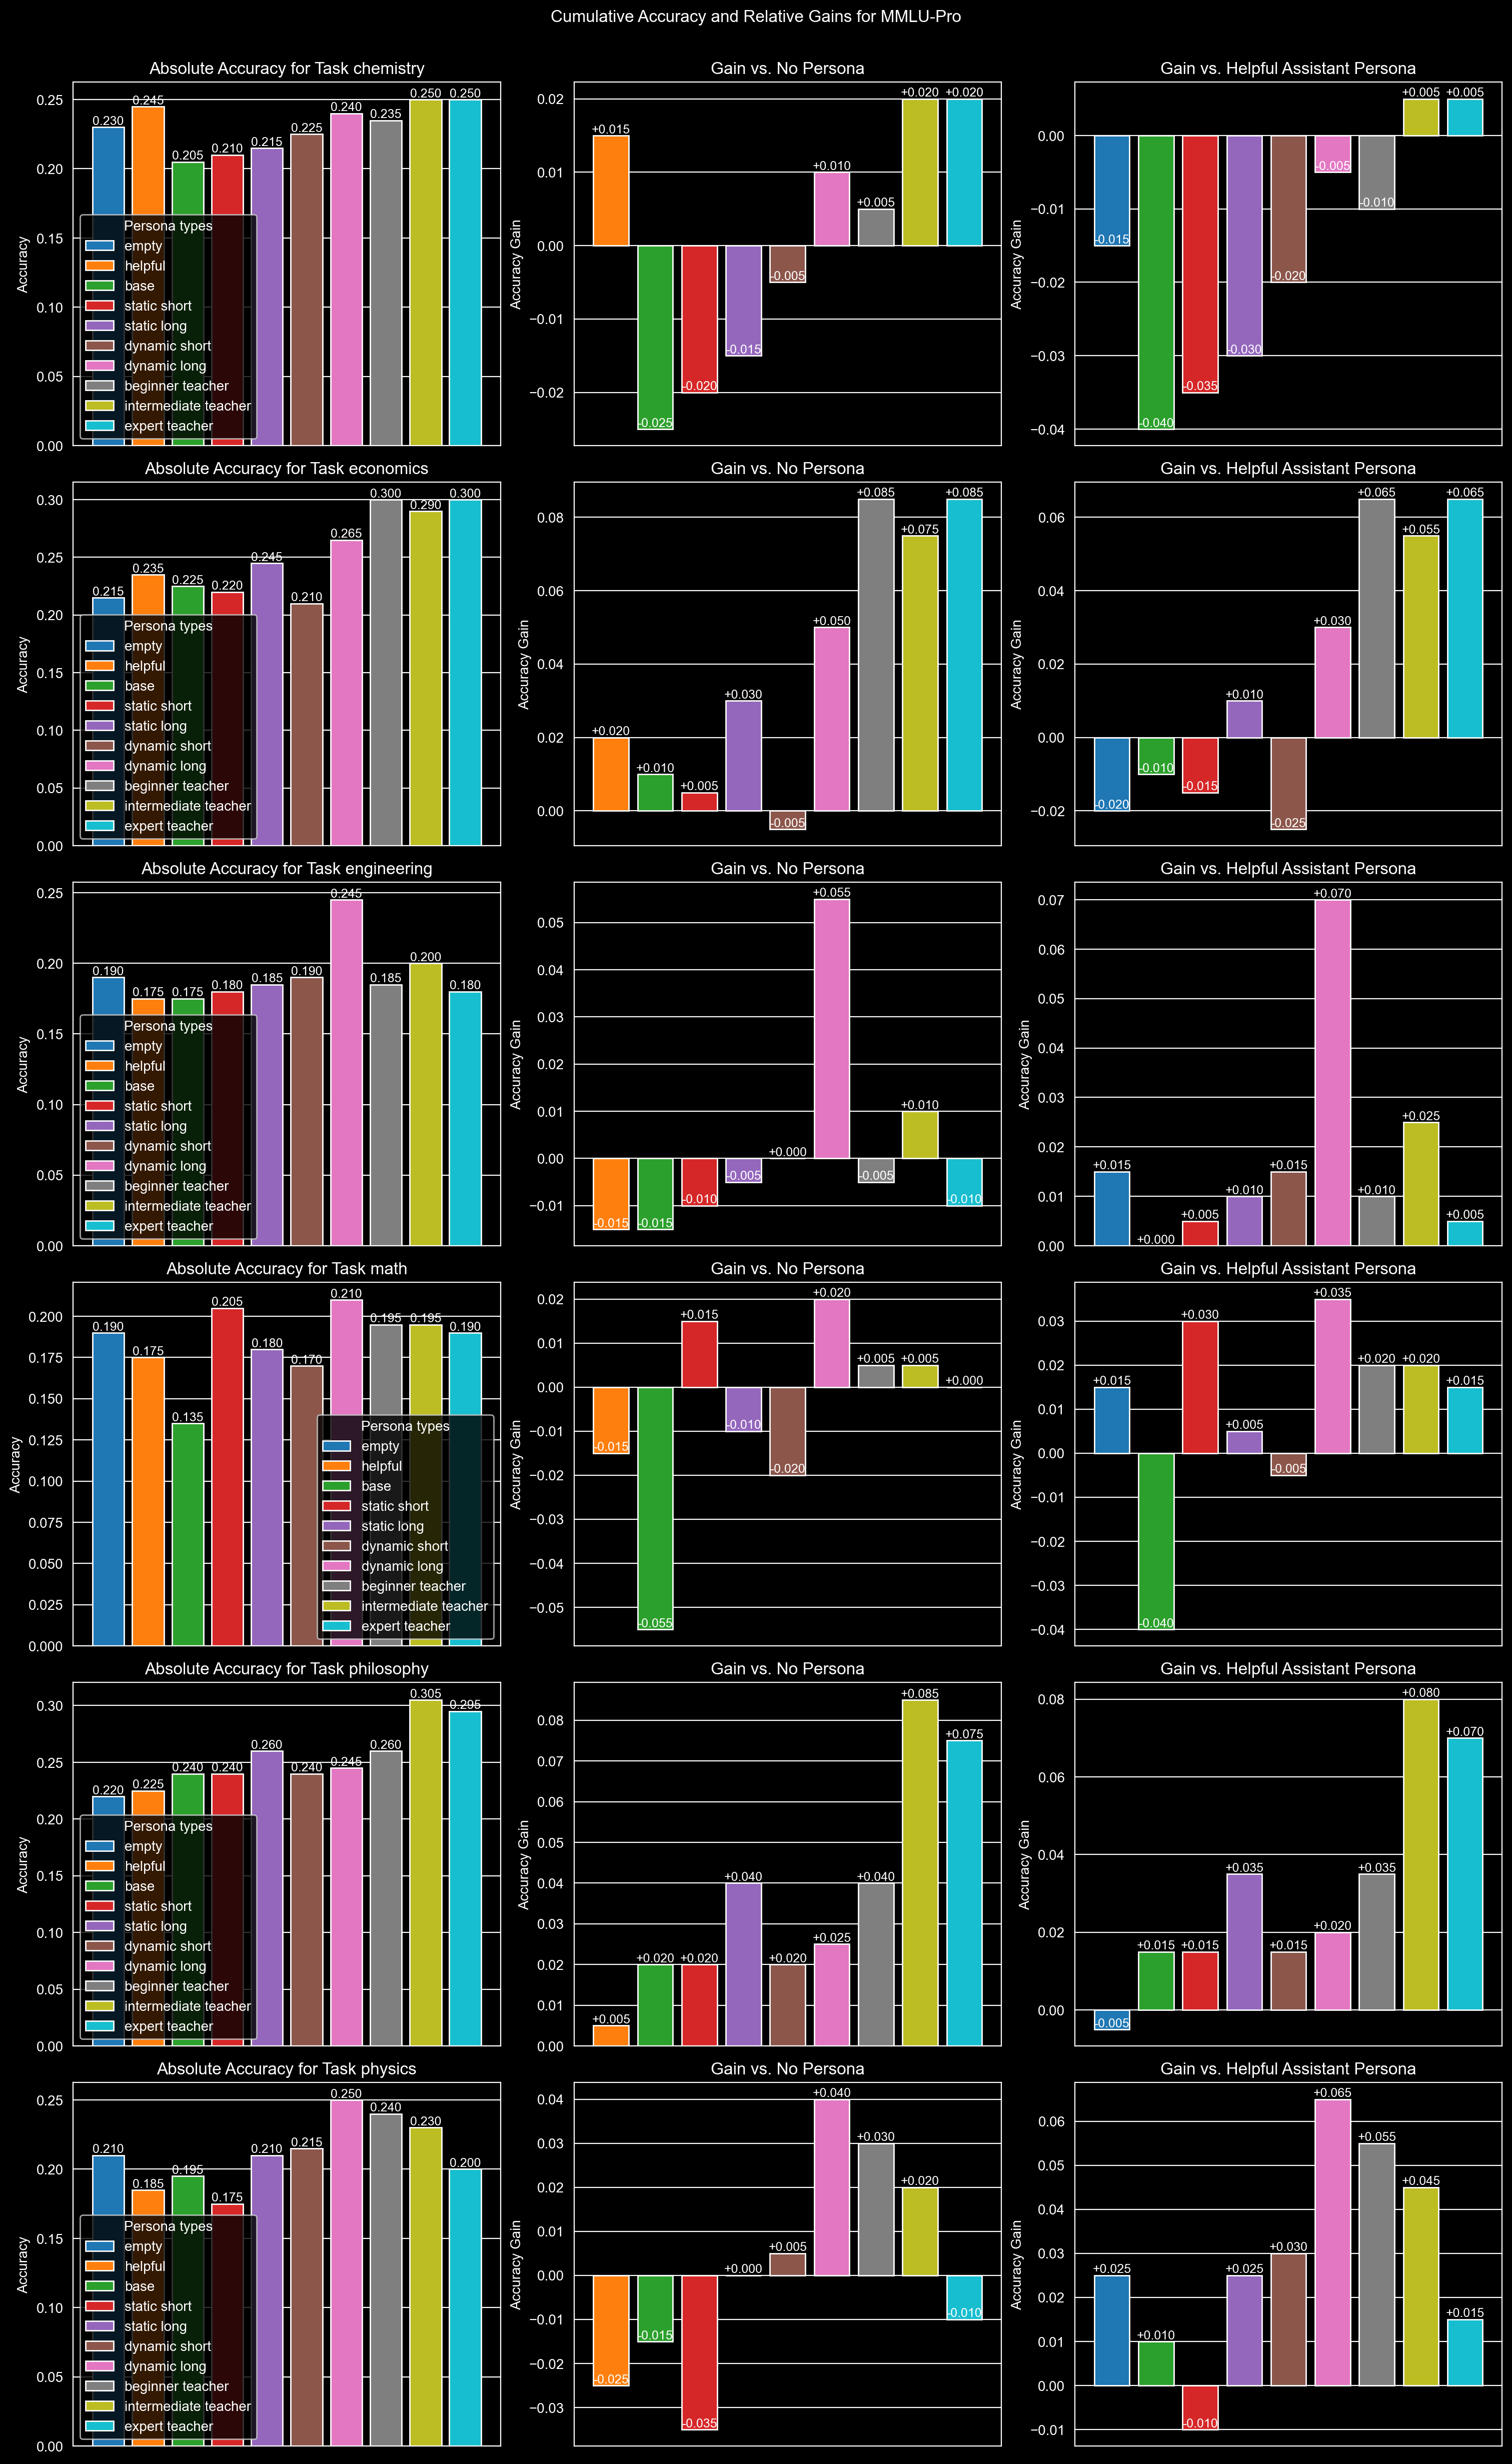

In [104]:
categories = accuracy_df["category"].tolist()

fig, axes = plt.subplots(
    nrows=len(categories),
    ncols=3,
    figsize=(15, len(categories) * 4),
    constrained_layout=True
)

for i, category in enumerate(categories):
    row_abs = get_plot_dict(accuracy_df, category, ignore_cols=["category"])
    row_base = get_plot_dict(gains_baseline_df, category, ignore_cols=["no"])
    row_help = get_plot_dict(gains_helpful_df, category, ignore_cols=["helpful"])

    plotting_wrapper.plot_abs_accuracy(axes[i][0], row_abs, title=f"Absolute Accuracy for Task {category}")
    plotting_wrapper.plot_rel_accuracy(axes[i][1], row_base, title=f"Gain vs. No Persona")
    plotting_wrapper.plot_rel_accuracy(axes[i][2], row_help, title=f"Gain vs. Helpful Assistant Persona")

fig.suptitle("Cumulative Accuracy and Relative Gains for MMLU-Pro", y=1.02)
fig.savefig(f"plots/mmlu-pro_{dataset_path}")
plt.show()

In [25]:
mmlu_effects_df = mmlu_df.copy()
for col in completion_columns:
    mmlu_effects_df[col] = (mmlu_effects_df["answer"] == mmlu_effects_df[col]).astype("int")

### Category chemistry

In [26]:
run_test_categorical(mmlu_effects_df, completion_columns, "chemistry")

0
base                    0.620191
beginner_teacher        0.868792
dynamic_long            0.069198
dynamic_short           0.013216
expert_teacher          0.186319
helpful                 1.000000
intermediate_teacher    0.321607
static_long             0.868792
static_short            0.868792
dtype: float64

In [27]:
run_test_dynamic(mmlu_effects_df, "chemistry")

persona    0.440741
dtype: float64

In [29]:
run_test_static(mmlu_effects_df, "chemistry")

persona    0.784086
dtype: float64

In [30]:
test_static_vs_dynamic(mmlu_effects_df, "chemistry")

is_dynamic    0.004223
dtype: float64

### Category economics

In [31]:
run_test_categorical(mmlu_effects_df, completion_columns, "economics")

0
base                    0.096645
beginner_teacher        0.139743
dynamic_long            0.026752
dynamic_short           0.711988
expert_teacher          0.711988
helpful                 0.096645
intermediate_teacher    0.711988
static_long             0.579729
static_short            0.853548
dtype: float64

In [32]:
run_test_dynamic(mmlu_effects_df, "economics")

persona    0.000571
dtype: float64

In [33]:
run_test_static(mmlu_effects_df, "economics")

persona    0.502074
dtype: float64

In [34]:
test_static_vs_dynamic(mmlu_effects_df, "economics")

is_dynamic    0.002681
dtype: float64

### Category math

In [35]:
run_test_categorical(mmlu_effects_df, completion_columns, "math")

0
base                    0.735727
beginner_teacher        1.000000
dynamic_long            0.612663
dynamic_short           0.612663
expert_teacher          0.865986
helpful                 0.735727
intermediate_teacher    0.612663
static_long             0.128805
static_short            0.398784
dtype: float64

In [36]:
run_test_dynamic(mmlu_effects_df, "math")

persona    0.330791
dtype: float64

In [37]:
run_test_static(mmlu_effects_df, "math")

persona    0.226209
dtype: float64

In [38]:
test_static_vs_dynamic(mmlu_effects_df, "math")

is_dynamic    0.169438
dtype: float64

### Category physics

In [39]:
run_test_categorical(mmlu_effects_df, completion_columns, "physics")

0
base                    0.871911
beginner_teacher        0.197101
dynamic_long            0.628602
dynamic_short           1.000000
expert_teacher          0.747101
helpful                 0.333348
intermediate_teacher    0.036081
static_long             0.076137
static_short            0.076137
dtype: float64

In [40]:
run_test_dynamic(mmlu_effects_df, "physics")

persona    0.49991
dtype: float64

In [41]:
run_test_static(mmlu_effects_df, "physics")

persona    0.081268
dtype: float64

In [42]:
test_static_vs_dynamic(mmlu_effects_df, "physics")

is_dynamic    0.148358
dtype: float64

### Category philosophy

In [43]:
run_test_categorical(mmlu_effects_df, completion_columns, "philosophy")

0
base                    0.581986
beginner_teacher        0.098645
dynamic_long            0.000024
dynamic_short           0.001812
expert_teacher          0.000116
helpful                 0.462960
intermediate_teacher    0.000054
static_long             0.027669
static_short            0.027669
dtype: float64

In [44]:
run_test_dynamic(mmlu_effects_df, "philosophy")

persona    0.001817
dtype: float64

In [45]:
run_test_static(mmlu_effects_df, "philosophy")

persona    0.153515
dtype: float64

In [46]:
test_static_vs_dynamic(mmlu_effects_df, "philosophy")

is_dynamic    0.002163
dtype: float64

### Category engineering

In [47]:
run_test_categorical(mmlu_effects_df, completion_columns, "engineering")

0
base                    0.877773
beginner_teacher        0.758397
dynamic_long            0.758397
dynamic_short           0.356133
expert_teacher          0.644526
helpful                 0.877773
intermediate_teacher    0.218568
static_long             0.124065
static_short            0.218568
dtype: float64

In [48]:
run_test_dynamic(mmlu_effects_df, "engineering")

persona    0.91808
dtype: float64

In [49]:
run_test_static(mmlu_effects_df, "engineering")

persona    0.040458
dtype: float64

In [50]:
test_static_vs_dynamic(mmlu_effects_df, "engineering")

is_dynamic    0.465888
dtype: float64

## MATH Evaluation

In [105]:
math_tasks, math_df = evaluator.get_data("MATH")
math_df = extract_answers(math_df, answer_columns, "math")

In [106]:
accuracy_df = compute_accuracy_df(math_df, completion_columns, ground_truth_col="answers", category_col="subject")
gains_baseline_df = compute_accuracy_difference(
    accuracy_df, "no", ["helpful"], category_col="subject")
gains_helpful_df = compute_accuracy_difference(
    accuracy_df, "helpful", ["no"], category_col="subject")

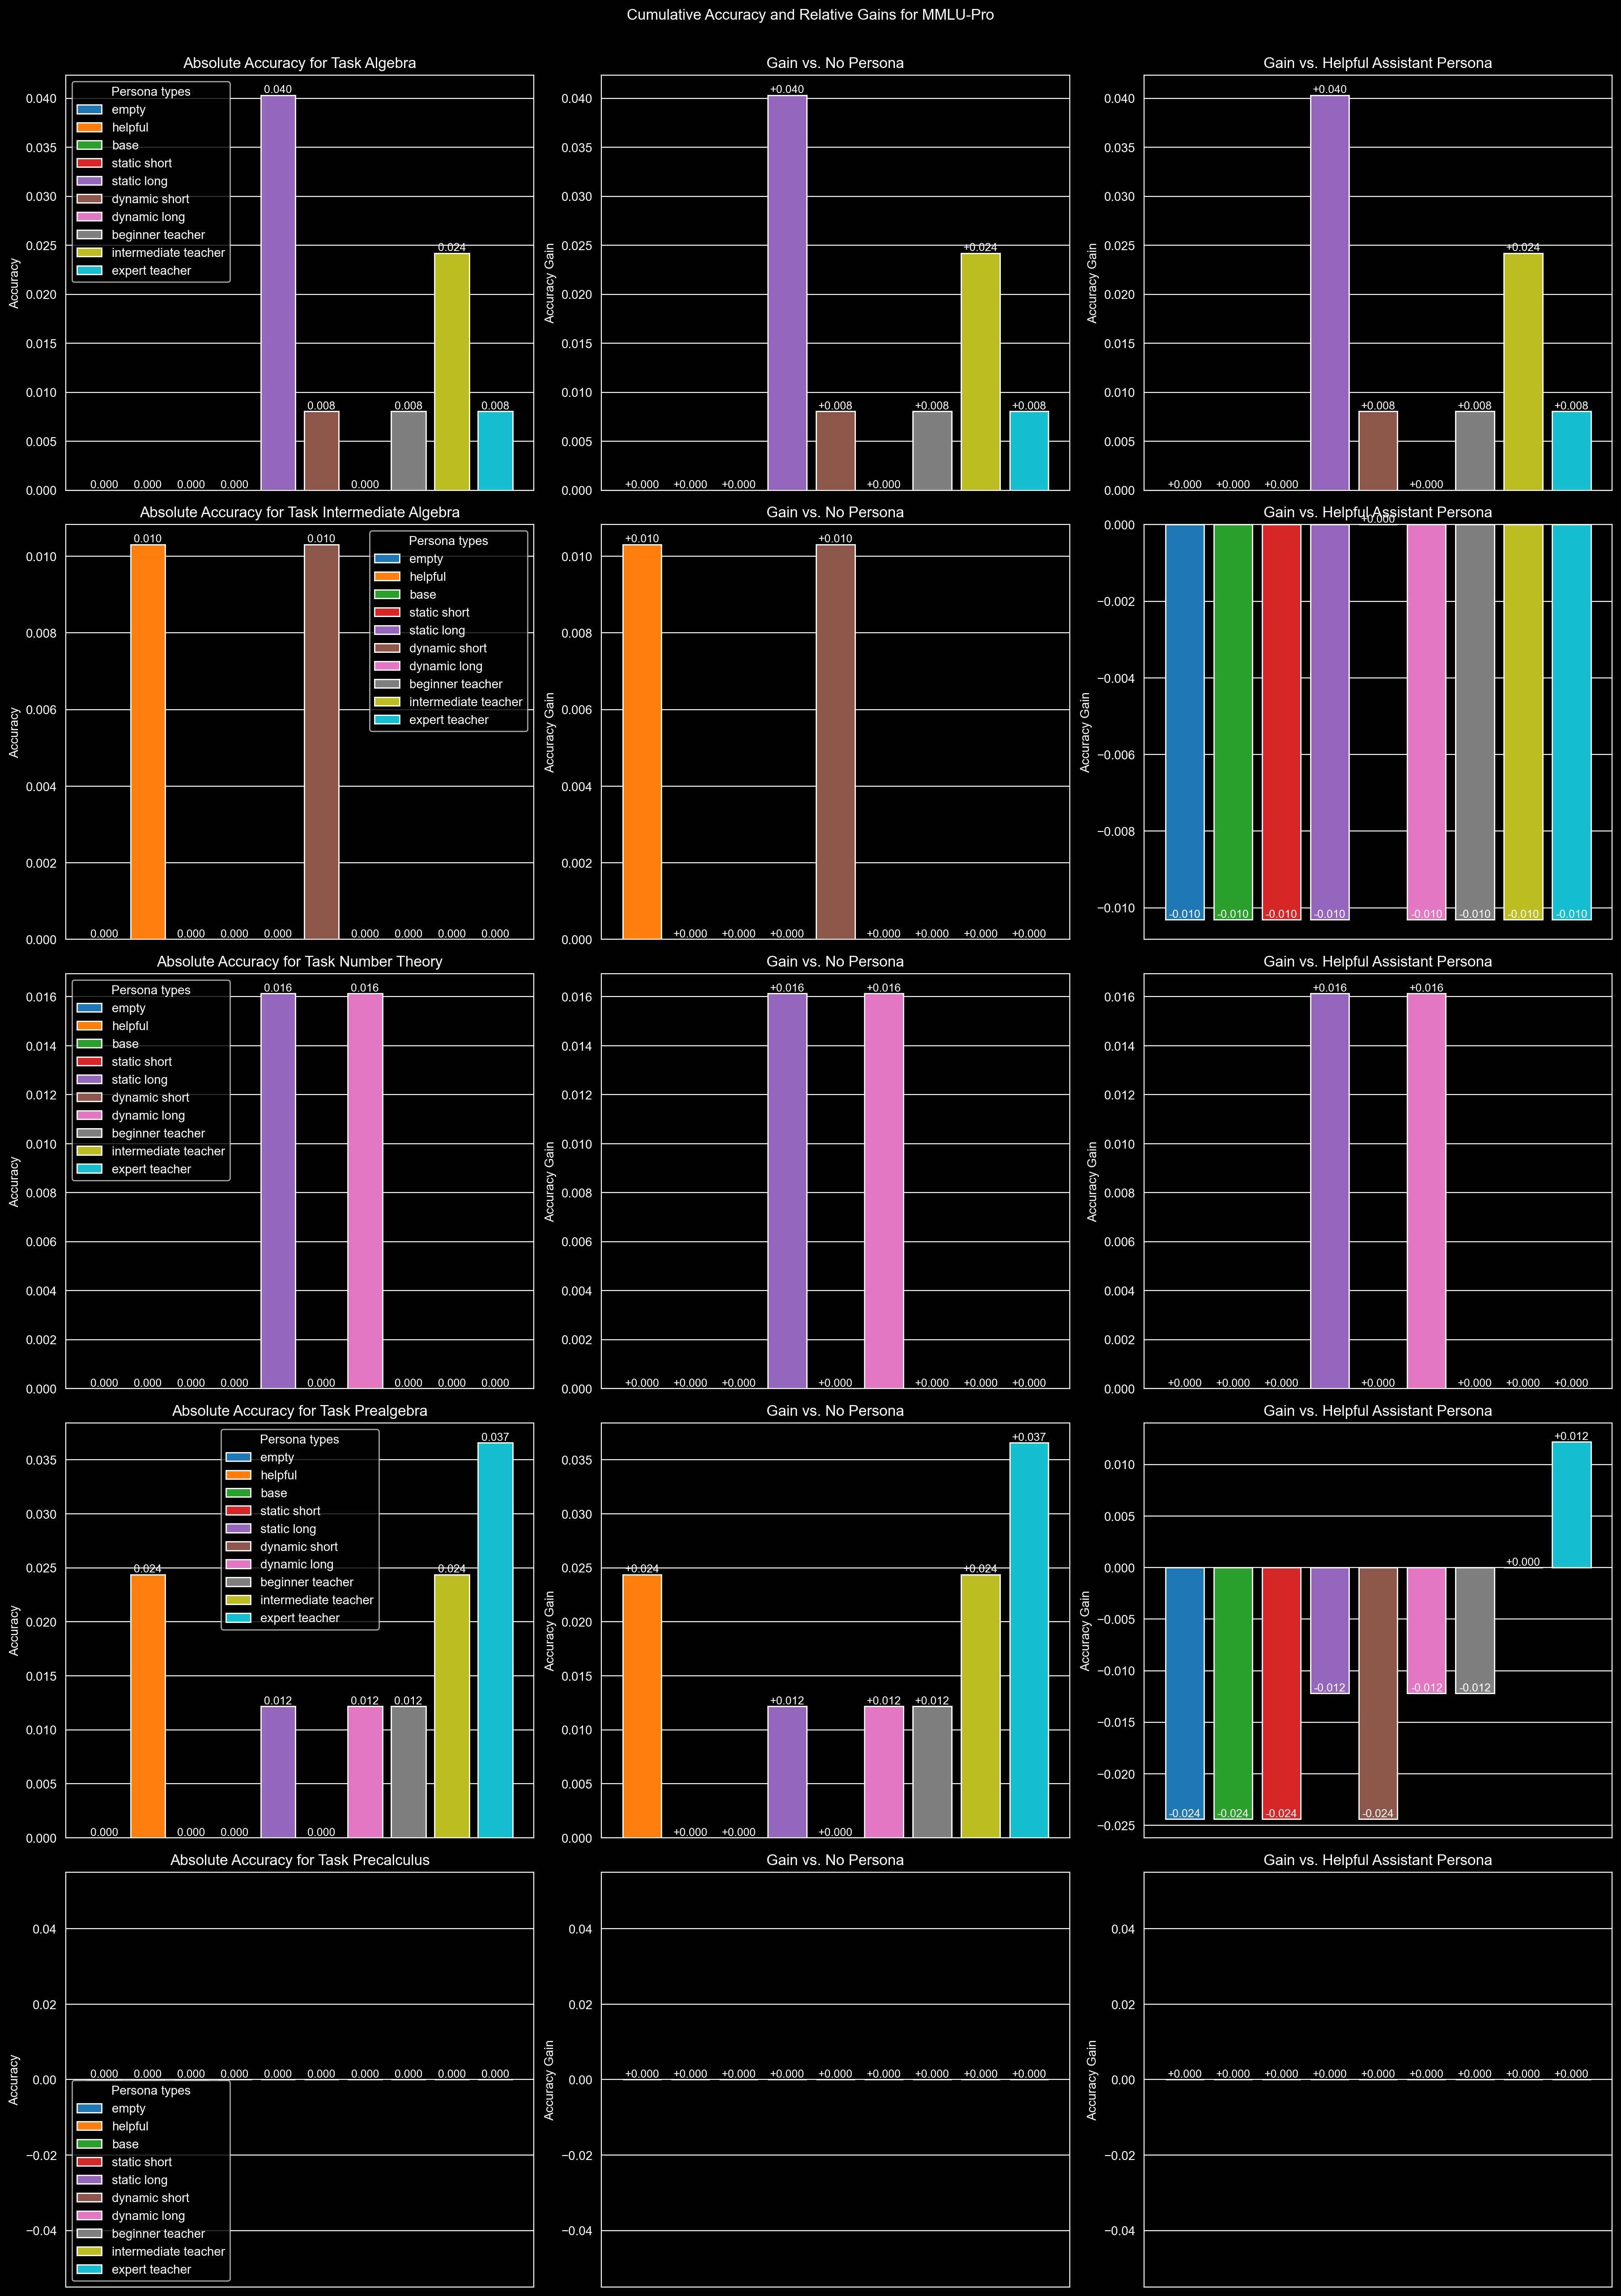

In [107]:
categories = accuracy_df["subject"].tolist()

fig, axes = plt.subplots(
    nrows=len(categories),
    ncols=3,
    figsize=(18, len(categories) * 5),
    constrained_layout=True
)

for i, category in enumerate(categories):
    row_abs = get_plot_dict(accuracy_df, category, category_col="subject")
    row_base = get_plot_dict(gains_baseline_df, category, category_col="subject", ignore_cols=["no"])
    row_help = get_plot_dict(gains_helpful_df, category, category_col="subject", ignore_cols=["helpful"])

    plotting_wrapper.plot_abs_accuracy(axes[i][0], row_abs, title=f"Absolute Accuracy for Task {category}")
    plotting_wrapper.plot_rel_accuracy(axes[i][1], row_base, title=f"Gain vs. No Persona")
    plotting_wrapper.plot_rel_accuracy(axes[i][2], row_help, title=f"Gain vs. Helpful Assistant Persona")

fig.suptitle("Cumulative Accuracy and Relative Gains for MMLU-Pro", y=1.02)
fig.savefig(f"plots/math_{dataset_path}")
plt.show()

In [81]:
math_effects_df = math_df.copy()
for col in completion_columns:
    math_effects_df[col] = (math_effects_df["answers"] == math_effects_df[col]).astype("int")

### Category Precalculus

In [82]:
run_test_categorical(math_effects_df, completion_columns, "Precalculus", category_col="subject")

0
base                    0.294418
beginner_teacher        0.431657
dynamic_long            0.431657
dynamic_short           0.035997
expert_teacher          0.793229
helpful                 0.115784
intermediate_teacher    0.793229
static_long             0.600112
static_short            0.793229
dtype: float64

In [83]:
run_test_dynamic(math_effects_df, "Precalculus", category_col="subject")

persona    0.543062
dtype: float64

In [84]:
run_test_static(math_effects_df, "Precalculus", category_col="subject")

persona    0.133578
dtype: float64

In [85]:
test_static_vs_dynamic(math_effects_df, "Precalculus", category_col="subject")

is_dynamic    0.089527
dtype: float64

### Category Intermediate Algebra

In [86]:
run_test_categorical(math_effects_df, completion_columns, "Intermediate Algebra", category_col="subject")

0
base                    0.829916
beginner_teacher        0.667473
dynamic_long            0.519298
dynamic_short           0.519298
expert_teacher          0.829916
helpful                 0.390210
intermediate_teacher    0.829916
static_long             0.519298
static_short            0.519298
dtype: float64

In [87]:
run_test_dynamic(math_effects_df, "Intermediate Algebra", category_col="subject")

persona    0.480863
dtype: float64

In [88]:
run_test_static(math_effects_df, "Intermediate Algebra", category_col="subject")

persona    0.745043
dtype: float64

In [89]:
test_static_vs_dynamic(math_effects_df, "Intermediate Algebra", category_col="subject")

is_dynamic    0.070566
dtype: float64

### Category Algebra

In [90]:
run_test_categorical(math_effects_df, completion_columns, "Algebra", category_col="subject")

0
base                    0.348783
beginner_teacher        0.348783
dynamic_long            0.851354
dynamic_short           0.453518
expert_teacher          0.189610
helpful                 1.000000
intermediate_teacher    0.260867
static_long             0.707823
static_short            0.707823
dtype: float64

In [91]:
run_test_dynamic(math_effects_df, "Algebra", category_col="subject")

persona    0.802718
dtype: float64

In [92]:
run_test_static(math_effects_df, "Algebra", category_col="subject")

persona    0.315954
dtype: float64

In [93]:
test_static_vs_dynamic(math_effects_df, "Algebra", category_col="subject")

is_dynamic    0.593028
dtype: float64

### Category Number Theory

In [94]:
run_test_categorical(math_effects_df, completion_columns, "Number Theory", category_col="subject")

0
base                    1.000000
beginner_teacher        1.000000
dynamic_long            1.000000
dynamic_short           0.581728
expert_teacher          0.581728
helpful                 0.098415
intermediate_teacher    0.782985
static_long             1.000000
static_short            0.782985
dtype: float64

In [95]:
run_test_dynamic(math_effects_df, "Number Theory", category_col="subject")

persona    0.843502
dtype: float64

In [96]:
run_test_static(math_effects_df, "Number Theory", category_col="subject")

persona    0.908462
dtype: float64

In [97]:
test_static_vs_dynamic(math_effects_df, "Number Theory", category_col="subject")

is_dynamic    0.526293
dtype: float64

### Category Prealgebra

In [98]:
run_test_categorical(math_effects_df, completion_columns, "Prealgebra", category_col="subject")

0
base                    0.181098
beginner_teacher        1.000000
dynamic_long            0.025816
dynamic_short           0.181098
expert_teacher          0.655746
helpful                 0.118694
intermediate_teacher    0.372614
static_long             0.014212
static_short            0.003760
dtype: float64

In [99]:
run_test_dynamic(math_effects_df, "Prealgebra", category_col="subject")

persona    0.287131
dtype: float64

In [100]:
run_test_static(math_effects_df, "Prealgebra", category_col="subject")

persona    0.428003
dtype: float64

In [101]:
test_static_vs_dynamic(math_effects_df, "Prealgebra", category_col="subject")

is_dynamic    0.455315
dtype: float64

## Flores Evaluation

In [108]:
flores_tasks, flores_df = evaluator.get_data("flores")
judgment_columns = persona_registry.get_judgment_columns()
flores_answer = extract_answers(flores_df, judgment_columns, "flores")

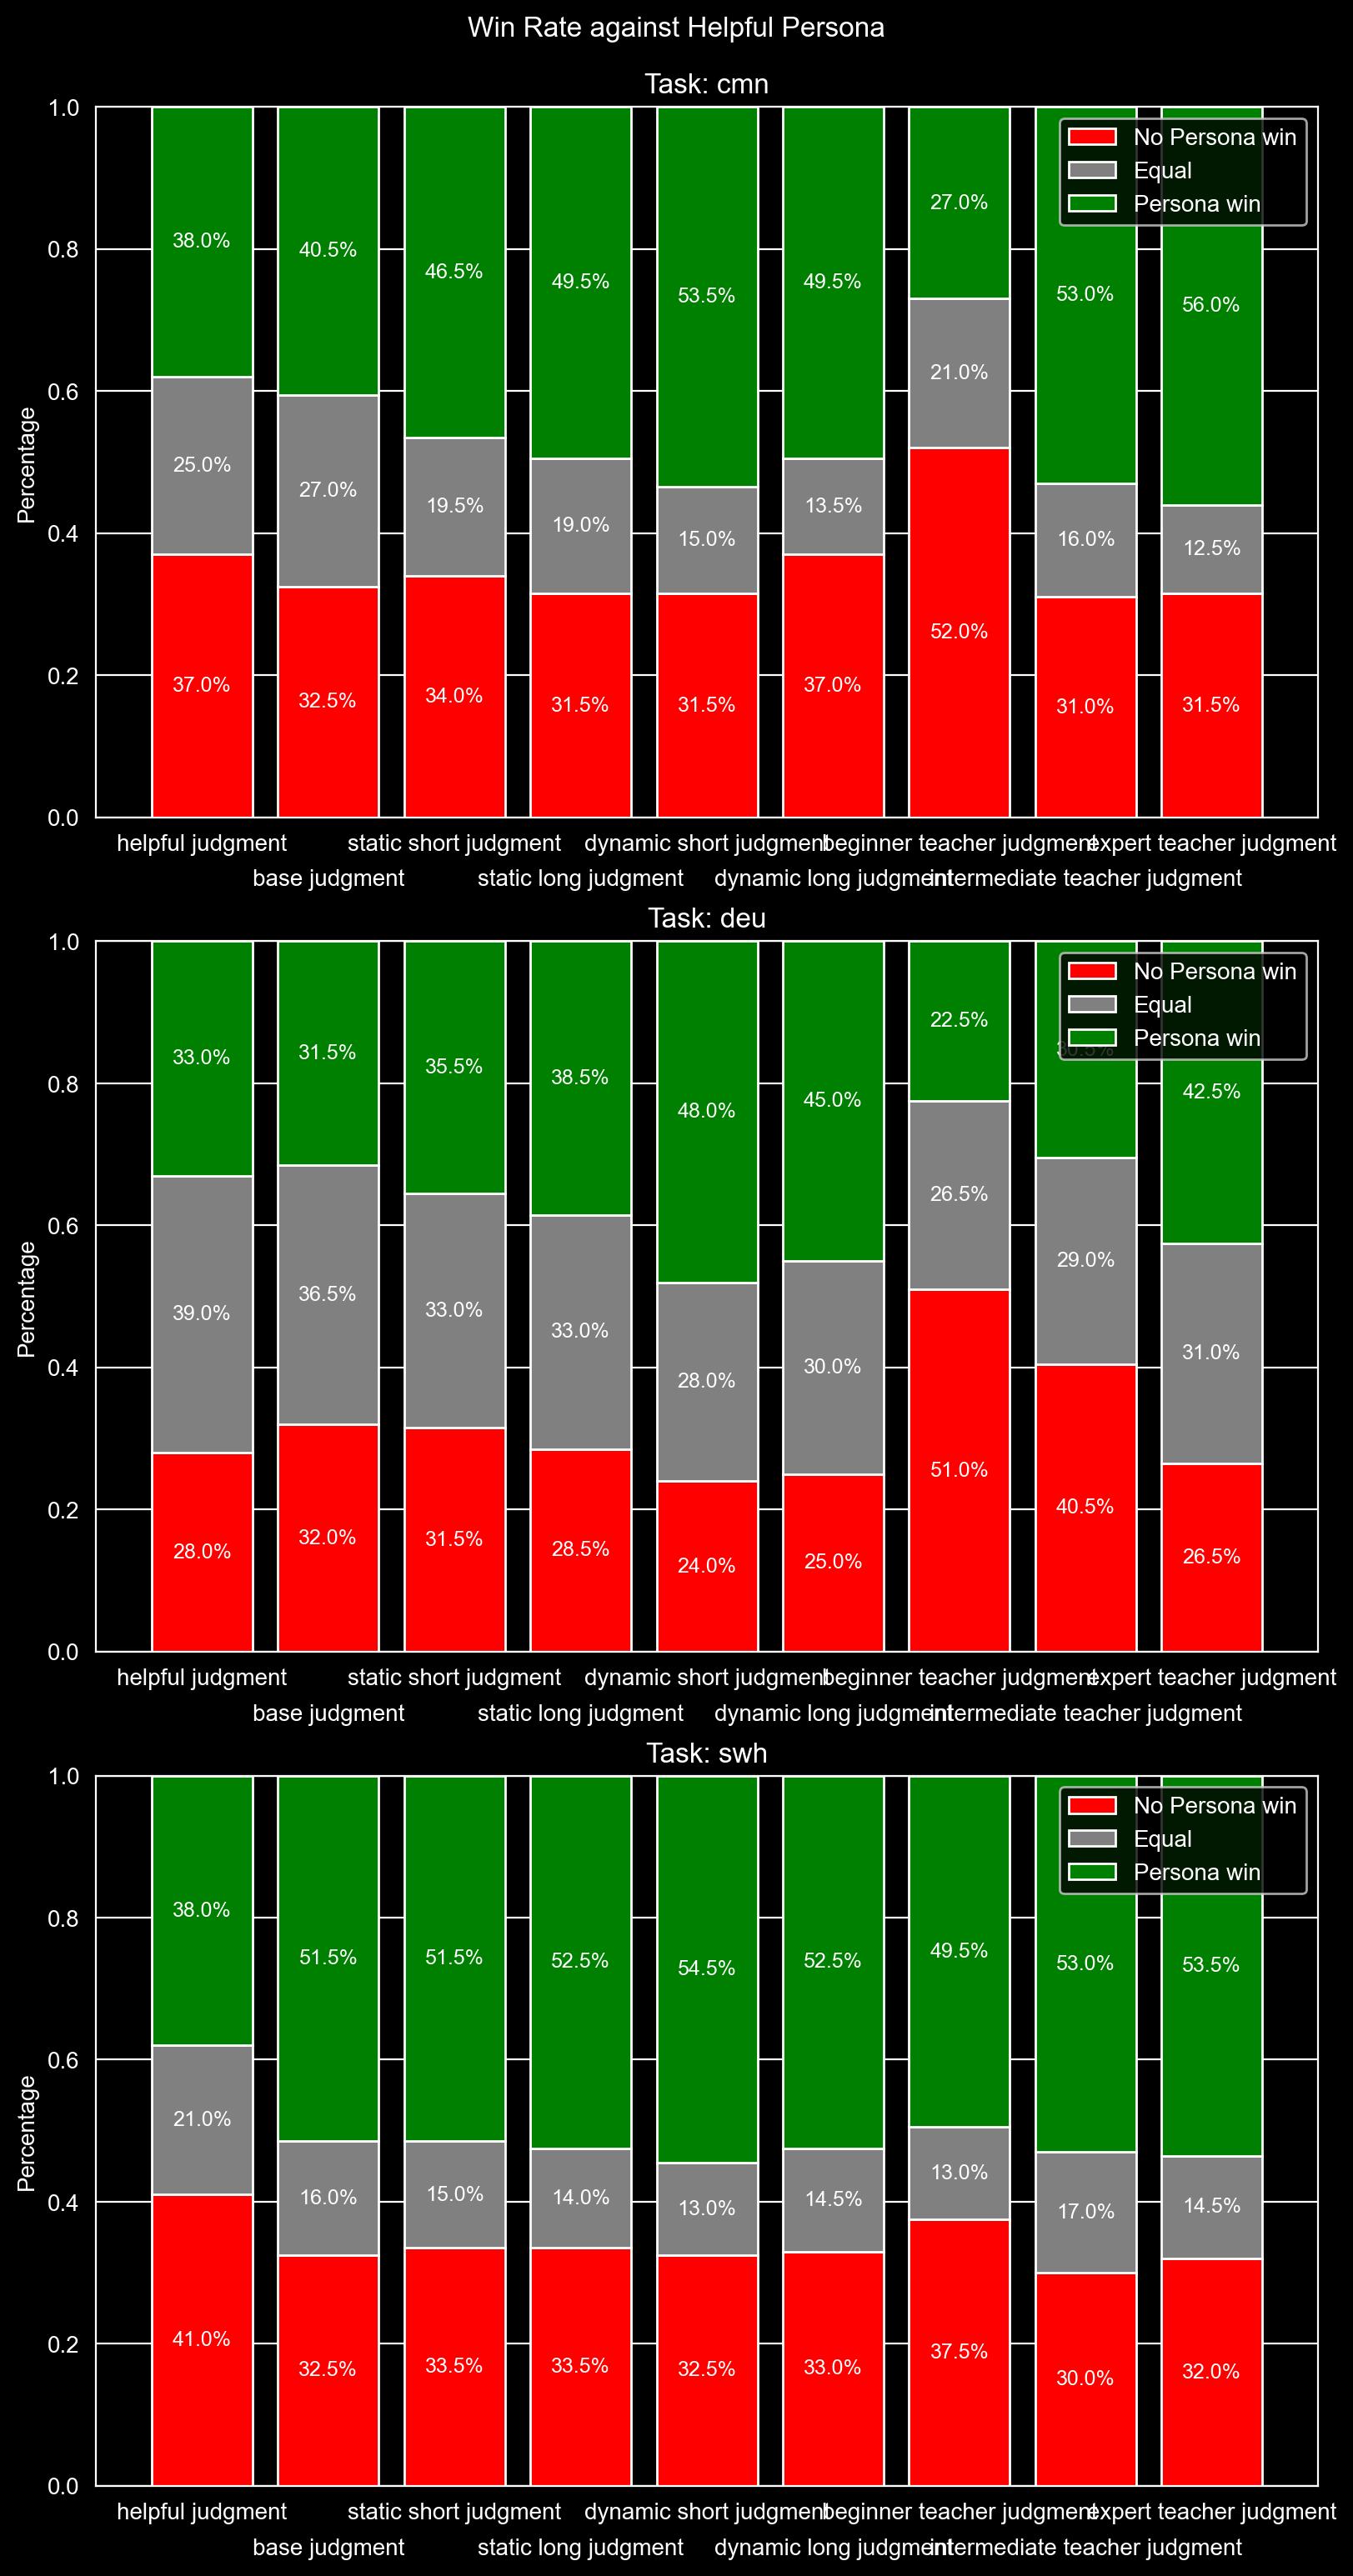

In [110]:
flores_data = get_plot_dict_stacked(flores_answer, judgment_columns, "iso_639_3")

categories = list(flores_data.keys())

fig, axes = plt.subplots(
    nrows=len(categories),
    ncols=1,
    figsize=(8, len(categories) * 5),
    constrained_layout=True
)

for ax, category in zip(axes, categories):
    category_data = flores_data[category]
    plotting_wrapper.plot_stacked_barchart(ax, category_data, judgment_columns, title=f"Task: {category}")

fig.suptitle("Win Rate against Helpful Persona", y=1.02)
fig.savefig(f"plots/flores_{dataset_path}")
plt.show()

In [44]:
flores_effects_df = flores_answer.copy()
flores_effects_df["iso_639_3"].unique()

array(['cmn', 'deu', 'swh'], dtype=object)

### Category cmn

In [103]:
test_flores(flores_effects_df, completion_columns, "cmn")

base                    0.125666
beginner_teacher        0.036725
dynamic_long            0.009973
dynamic_short           0.097834
expert_teacher          0.096363
helpful                 0.346381
intermediate_teacher    0.000004
static_long             0.073999
static_short            0.000878
dtype: float64

In [104]:
run_test_dynamic(flores_effects_df, "cmn", "iso_639_3", "flores")

persona    0.35076
dtype: float64

In [105]:
run_test_static(flores_effects_df, "cmn", "iso_639_3", "flores")

persona    0.661242
dtype: float64

In [106]:
test_static_vs_dynamic(flores_effects_df, "cmn", category_col="iso_639_3", dataset_preprocess="flores")

is_dynamic    0.975085
dtype: float64

### Category deu

In [107]:
test_flores(flores_effects_df, completion_columns, "deu")

base                    0.573922
beginner_teacher        0.963393
dynamic_long            0.013972
dynamic_short           0.057727
expert_teacher          0.045885
helpful                 0.824437
intermediate_teacher    0.000005
static_long             0.069377
static_short            0.642987
dtype: float64

In [108]:
run_test_dynamic(flores_effects_df, "deu", "iso_639_3", "flores")

persona    0.098973
dtype: float64

In [109]:
run_test_static(flores_effects_df, "deu", "iso_639_3", "flores")

persona    0.116947
dtype: float64

In [110]:
test_static_vs_dynamic(flores_effects_df, "deu", category_col="iso_639_3", dataset_preprocess="flores")

is_dynamic    0.072403
dtype: float64

### Category swh

In [111]:
test_flores(flores_effects_df, completion_columns, "swh")

base                    0.221858
beginner_teacher        0.167568
dynamic_long            0.003066
dynamic_short           0.009184
expert_teacher          0.001287
helpful                 0.201552
intermediate_teacher    0.001203
static_long             0.005028
static_short            0.002715
dtype: float64

In [112]:
run_test_dynamic(flores_effects_df, "swh", "iso_639_3", "flores")

persona    0.200482
dtype: float64

In [113]:
run_test_static(flores_effects_df, "swh", "iso_639_3", "flores")

persona    0.463168
dtype: float64

In [114]:
test_static_vs_dynamic(flores_effects_df, "swh", category_col="iso_639_3", dataset_preprocess="flores")

is_dynamic    0.640035
dtype: float64